In [57]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [194]:
import numpy as np
import CustomModules.util as util
import plotly.express as px
import torch.nn as nn
import torch
import CustomModules.A_CAE as A_CAE
import CustomModules.A_AE as A_AE
from datasets import load_dataset
import matplotlib.pyplot as plt
from sklearn.datasets import make_s_curve
import copy

In [59]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
s_data, _ = make_s_curve(n_samples=1000, noise=0.05, random_state=0)
s_data_test, _ = make_s_curve(n_samples=1000, noise=0.05, random_state=1)
util.plot3d([(s_data, "S-Curve Dataset")], title="Double Torus") 

In [61]:
torus_data = util.generate_torus(10000)
torus_data_test = util.generate_torus(10000)
util.plot3d([(torus_data, "torus data")], title="Double Torus")

In [156]:
X_train = torch.tensor(torus_data, dtype=torch.float32)
X_test = torch.tensor(torus_data_test, dtype=torch.float32)
X_loader_train = torch.utils.data.DataLoader(X_train, batch_size=1024, shuffle=True)
X_loader_test = torch.utils.data.DataLoader(X_test, batch_size=1024, shuffle=True)

In [159]:

def reconstruct(model_name, data):
    if model_name == "ae":
        ae.to("cpu")
        reconstructed = ae.decode(ae.encode(data)).detach().numpy()
        reconstructed.shape
        return reconstructed
    if model_name == "cae":
        cae.to("cpu")
        probabilities = cae.predict(data)
        alpha = torch.argmax(probabilities, dim=1)
        reconstructed = cae.encode_decode(data).detach().numpy()
        return reconstructed, alpha


In [161]:
ae = A_AE.AE(3,2,15)

In [162]:
A_AE.train_ae(num_epochs=1000, x_train_loader=X_loader_train, network=ae, device=device)

100%|██████████| 1000/1000 [00:39<00:00, 25.54it/s]


In [163]:
reconstructed = reconstruct("ae", X_train[0:10000])
util.plot3d([(reconstructed, "reconstructed")], title="Double Torus")

In [ ]:
cae = A_CAE.CAE(x_dim=3, w_dim=3, z_dim=2, outer_structure=[10, 10], hidden_structure=[15, 15], predictor_structure=[10, 10], chart_amount=25, activation_outer=nn.Identity(), activation=nn.Tanh())

A_CAE.pre_train_cae(num_epochs=300, x_train=X_train, network=cae, device = device, lr=1e-2)
pretrained = copy.deepcopy(cae)

100%|██████████| 300/300 [00:15<00:00, 18.94it/s]


In [217]:
diag = A_CAE.train_cae(num_epochs=40, x_train_loader=X_loader_train, network=cae, device=device, lr=5e-4)
posttrained = copy.deepcopy(cae)

100%|██████████| 40/40 [00:23<00:00,  1.74it/s]


In [218]:
cae = posttrained
reconstructed, alpha = reconstruct("cae", X_train[0:10000])
util.plot3d([(reconstructed, "reconstructed")], title="Double Torus", color=[alpha.detach().numpy()])

In [78]:
with torch.no_grad():
    probabilities = cae.predict(X_test)
    alpha = torch.argmax(probabilities, dim=1)

util.plot3d(
    [(X_test, "original torus")],
    color=[alpha.numpy()]
)

In [68]:
cae.state_dict()

OrderedDict([('encoder.network.0.weight',
              tensor([[ 0.7087, -1.0874,  0.0173],
                      [-0.6583, -0.1873, -0.7990],
                      [ 0.5334,  0.4715, -0.5807]])),
             ('encoder.network.0.bias', tensor([ 0.0817, -0.2248, -0.2998])),
             ('decoder.network.0.weight',
              tensor([[ 0.4092, -0.4589,  0.7668],
                      [-0.6695, -0.3740,  0.4250],
                      [ 0.0163, -0.1233, -0.0713]])),
             ('decoder.network.0.bias', tensor([ 0.0933,  0.0947, -0.0067])),
             ('chart_predictor.network.0.weight',
              tensor([[-0.0593,  0.0149, -1.3216],
                      [ 0.3500,  0.6233,  0.3698],
                      [ 0.3117, -0.0889,  0.6501],
                      [-0.0706,  0.5848, -0.0254],
                      [-0.2283,  0.5110,  0.2290],
                      [ 0.0457, -0.0892, -0.7294],
                      [ 0.1472,  0.3954,  0.1628],
                      [-0.1533, -0.2678, 

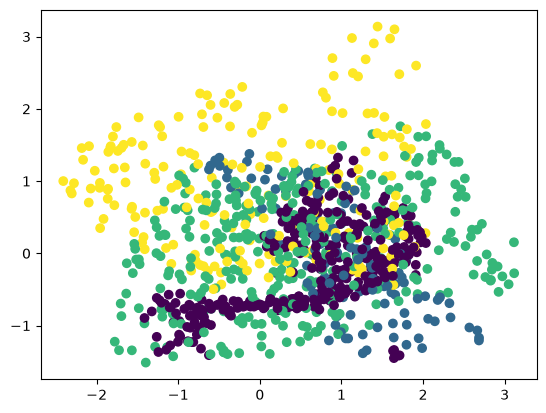

In [155]:
probabilities = cae.predict(X_test)
alpha = torch.argmax(probabilities, dim=1)
middle = cae.encode(X_test)
latent = cae.chart_multi_encode(middle, alpha).detach().numpy()
plt.scatter(latent[:, 0], latent[:, 1], c=alpha.detach().numpy())

In [70]:
probabilities = cae.predict(X_test)
alpha = torch.argmax(probabilities, dim=1)
middle = cae.encode(X_test)
latent = cae.chart_multi_encode(middle, alpha).detach().numpy()
util.plot3d([(latent, "latent"),], title="Double Torus Latent Space")

ValueError: cannot reshape array of size 20000 into shape (3)